**DEDUPLICATING FAIRSHARING RECORDS & GOOGLE SHEETS**

In [153]:
import pandas as pd
import re
from rapidfuzz import fuzz, process
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [109]:
# read in saved csvs again
df_covid = pd.read_csv("data/covid_databases.csv", dtype={"year_created": str})
df_top_similarity = pd.read_csv("data/similar_databases.csv", dtype={"year_created": str})

In [187]:
df_covid.head(20)[['name', 'cross_references']]

,name,cross_references
0,COVID-19 Data Repository,NaN
1,AccessClinicalData@NIAID,NaN
2,Addgene,https://www.re3data.org/repository/r3d10001074...
3,Alliance of Genome Resources,NaN
4,American Society of Clinical Oncology (ASCO) S...,NaN
5,Antibody Registry,https://www.re3data.org/repository/r3d10001040...
6,Arca Dados,https://www.re3data.org/repository/r3d100013904
7,BBMRI-ERIC Directory,https://www.re3data.org/repository/r3d100013028
8,Better Outcomes Registry & Network,https://www.re3data.org/repository/r3d100013917
9,BioData.pt Data Management Portal,NaN


In [111]:
# read google sheet csv
google_sheet = pd.read_csv(
    "../COVID_google_sheet.csv",
    skiprows=1,  # skip row 1, so row 2 becomes the header
    usecols=["Acronym", "Full name", "Resource website"],  # keep only these columns
)

# drop rows where BOTH Acronym and Full name are empty/NaN
google_sheet = google_sheet.dropna(subset=["Acronym", "Full name"], thresh=1)

# clean up whitespace
google_sheet["Acronym"] = google_sheet["Acronym"].str.strip()
google_sheet["Full name"] = google_sheet["Full name"].str.strip()
google_sheet["Resource website"] = google_sheet["Resource website"].str.strip()

In [112]:
print(f"Number of rows after cleaning: {len(google_sheet)}")
google_sheet.head(50)

Number of rows after cleaning: 487


,Acronym,Full name,Resource website
0,AAOS Registry Program (includes American Joint...,American Academy of Orthopaedic Surgeons,https://www.aaos.org/registries/covid-19-data/
1,ACR CIRR,American College of Radiology COVID-19 Imaging...,https://www.acr.org/Research/Clinical-Research...
2,ACS COVID-19 Registry (also called COVID-ACS),American College of Surgeons COVID-19 Registry,https://www.facs.org/quality-programs/covid19-...
3,COVID-ACS Registry,COVID-Acute Coronary Syndrome Registry,Not provided
4,AGMT COVID-19 Registry,Austrian COVID-19 Registry,https://www.agmt.at/register-covid-19/
5,ASH Research Collaborative COVID-19 Registry f...,American Society for Hematology Research Colla...,https://www.ashresearchcollaborative.org/s/cov...
6,ASCO Registry,American Society of Clinical Oncology Survey o...,https://www.asco.org/asco-coronavirus-informat...
7,B1MG and 1+MG,1 Million Genomes & Beyond 1 Million Genomes P...,https://b1mg-project.eu/about/
8,BADBIR,British Association of Dermatologists Biologic...,http://www.badbir.org/
9,BEAT19,"Behavior, Environment and Treatments for COVID...",https://beat19.org/


In [113]:
# function to extract ALL text from parentheses as alternative names
def extract_parenthesis_texts(text):
    """extract all text from parentheses, removing 'also called' prefix"""
    if pd.isna(text):
        return []
    
    texts = []
    matches = re.findall(r'\(([^()]+)\)', str(text))
    
    for inner in matches:
        inner = inner.strip()
        
        # remove "also called" prefix if present
        inner = re.sub(r'^also called\s*|^includes\s*', '', inner, flags=re.IGNORECASE)
        inner = inner.strip()
        
        if inner and len(inner) >= 2:
            texts.append(inner.lower())
    
    return texts


google_sheet['_parenthesis_texts'] = google_sheet['Acronym'].apply(extract_parenthesis_texts)

In [114]:
# function to remove parentheses content from text - because we already saved content of parentheses in a column
def remove_parentheses_content(text):
    """Remove everything in parentheses from text"""
    if pd.isna(text):
        return None
    
    # Remove everything in parentheses (including the parentheses)
    cleaned = re.sub(r'\s*\([^()]*\)', '', str(text))
    
    # Clean up extra whitespace
    cleaned = ' '.join(cleaned.split()).strip()
    
    return cleaned.lower() if cleaned else None

google_sheet['_normalized_acronym'] = google_sheet['Acronym'].apply(
    lambda x: remove_parentheses_content(x) if x else None
)

In [115]:
google_sheet.head()

,Acronym,Full name,Resource website,_parenthesis_texts,_normalized_acronym
0,AAOS Registry Program (includes American Joint...,American Academy of Orthopaedic Surgeons,https://www.aaos.org/registries/covid-19-data/,"[american joint replacement registry, shoulder...",aaos registry program
1,ACR CIRR,American College of Radiology COVID-19 Imaging...,https://www.acr.org/Research/Clinical-Research...,[],acr cirr
2,ACS COVID-19 Registry (also called COVID-ACS),American College of Surgeons COVID-19 Registry,https://www.facs.org/quality-programs/covid19-...,[covid-acs],acs covid-19 registry
3,COVID-ACS Registry,COVID-Acute Coronary Syndrome Registry,Not provided,[],covid-acs registry
4,AGMT COVID-19 Registry,Austrian COVID-19 Registry,https://www.agmt.at/register-covid-19/,[],agmt covid-19 registry


In [116]:
# need to actually remove content of parentheses from the full name column.. there's too much noise there
google_sheet['_normalized_fullname'] = google_sheet['Full name'].apply(
    lambda x: remove_parentheses_content(x) if x else None
)

In [117]:
# Build a combined list of possible names from google_sheet (the "bag of words" / reference list)
google_names = []

for _, row in google_sheet.iterrows():
    # Add all non-empty names from the 3 columns
    if row['_normalized_acronym']:
        google_names.append(row['_normalized_acronym'])
    if row['_normalized_fullname']:
        google_names.append(row['_normalized_fullname'])
    google_names.extend(row['_parenthesis_texts'])

# make unique and remove really short 'names'
google_names = list(set(google_names))
google_names = [name for name in google_names if len(name) >= 2]

In [118]:
google_names

['adjumed covid-19 register',
 'indn covid-19 childhood cancer registry',
 'cardiovid registry',
 'implementation network for sharing population information from reseasrch entities - platform for evaluation and analysis of covid-19 harmonized data',
 'international agency for research on cancer catalogue of registries',
 'consortium for clinical characterization of covid-19 by ehr',
 'european molecular biology laboratory-european bioinformatics institute electron microscopy public image archive',
 'the german rhadar registry',
 'giquic',
 'l’étude evanesco',
 'critical care asia platform',
 'you + me registry l covid-19',
 'ncrc',
 'american heart association covid-19 cardiovascular disease registry',
 'nih - ncbi',
 'global initiative on sharing all influenza data',
 'indn pediatric oncology group covid-19 registry',
 'musc-19',
 'formerly secure-cirrhosis',
 'canadian covid-19 genomics network - virusseq data portal',
 'intelligent research in sight registry',
 'the german rheumadat

In [119]:
def normalize_url_to_domain(url):
    """Extract domain from URL for matching"""
    if pd.isna(url) or not url or not str(url).strip():
        return None
    
    url = str(url).strip().lower()
    
    # Remove protocol
    url = re.sub(r'^https?://', '', url)
    
    # Remove trailing slash and everything after
    url = re.sub(r'[/].*$', '', url)
    
    # Remove www. prefix (NEW!)
    url = re.sub(r'^www\.', '', url)
    
    # Remove brackets, parentheses and other special chars (keep hyphens!)
    url = re.sub(r'[^\w\.-]', '', url)
    
    return url if url else None


# create normalized url column for google sheet
google_sheet['_normalized_domain'] = google_sheet['Resource website'].apply(normalize_url_to_domain)

# build set of normalized domains from google sheet
google_domains = set(google_sheet['_normalized_domain'].dropna().unique())

In [120]:
google_domains

{'aad.org',
 'aao.org',
 'aaos.org',
 'aap.org',
 'acadic.org',
 'acc.org',
 'acr.org',
 'adhok.de',
 'adjumed.com',
 'africaopendata.org',
 'agmt.at',
 'aidsmap.com',
 'airr-community.org',
 'alterstraumaregister-dgu.de',
 'amsterdammedicaldatascience.nl',
 'aphrc.org',
 'ardc.edu.au',
 'asco.org',
 'ashresearchcollaborative.org',
 'aus-covid.com',
 'auscr.com.au',
 'b1mg-project.eu',
 'badbir.org',
 'beat19.org',
 'bianca.science.uu.nl',
 'bioconductor.org',
 'biokeanos.com',
 'biolincc.nhlbi.nih.gov',
 'bornontario.ca',
 'brh.data-commons.org',
 'bsg.ox.ac.uk',
 'bsti.org.uk',
 'bsticovid19.cimar.co.uk',
 'bv-brc.org',
 'c-viper.pregistry.com',
 'cancerimagingarchive.net',
 'canvas-covid.ca',
 'capacity-covid.eu',
 'carragroup.org',
 'cart-wheel.org',
 'catalogue.bbmri.nl',
 'catalogue.rd-connect.eu',
 'catalyst.harvard.edu',
 'catie.ca',
 'cbligand.org',
 'ccc19.org',
 'ccedrrn.com',
 'cdc.gov',
 'cellimagelibrary.org',
 'cerner.com',
 'cff.org',
 'chicagoland.pandemicresponsecommo

In [133]:
# normalize df_covid
df_covid['_norm_name'] = df_covid['name'].str.lower().str.strip()
df_covid['_norm_abbreviation'] = df_covid['abbreviation'].str.lower().str.strip()
df_covid['_norm_domain'] = df_covid['url'].apply(normalize_url_to_domain)

# normalize df_top_similarity
df_top_similarity['_norm_name'] = df_top_similarity['name'].str.lower().str.strip()
df_top_similarity['_norm_abbreviation'] = df_top_similarity['abbreviation'].str.lower().str.strip()
df_top_similarity['_norm_domain'] = df_top_similarity['url'].apply(normalize_url_to_domain)

In [122]:
def mark_duplicates(df, google_names, google_domains, threshold=80):
    """
    Mark duplicates in df by checking against google sheet.
    
    Returns df with two new columns:
    - '_is_duplicate': True if matched
    - '_matched_to': Which google name it matched to
    """
    
    df['_is_duplicate'] = False
    df['_match_type'] = None
    df['_matched_to'] = None
    
    for idx, row in df.iterrows():
        matched = False
        
        # Check 1: URL/domain match (strongest)
        if pd.notna(row['_norm_domain']) and row['_norm_domain'] in google_domains:
            match_row = google_sheet[google_sheet['_normalized_domain'] == row['_norm_domain']].iloc[0]
            df.loc[idx, '_is_duplicate'] = True
            df.loc[idx, '_match_type'] = 'url'
            df.loc[idx, '_matched_to'] = match_row['Full name']
            continue
        
        # Check 2: Exact name match
        if pd.notna(row['_norm_name']) and row['_norm_name'] in google_names:
            df.loc[idx, '_is_duplicate'] = True
            df.loc[idx, '_match_type'] = 'exact_name'
            df.loc[idx, '_matched_to'] = row['_norm_name']
            continue
        
        # Check 3: Exact abbreviation match
        if pd.notna(row['abbreviation']) and row['abbreviation'] in google_names:
            df.loc[idx, '_is_duplicate'] = True
            df.loc[idx, '_match_type'] = 'exact_abbr'
            df.loc[idx, '_matched_to'] = row['abbreviation']
            continue
        
        # Check 4: Word overlap match (name) - at least 2 words must match
        #if pd.notna(row['_norm_name']):
         #   df_words = set(row['_norm_name'].split())
           # for google_name in google_names:
          #      google_words = set(google_name.split())
            #    if len(df_words & google_words) >= 2:
             #       df.loc[idx, '_is_duplicate'] = True
              #      df.loc[idx, '_match_type'] = 'word_overlap'
               #     df.loc[idx, '_matched_to'] = google_name
                #    matched = True
                 #   break

        #if matched:
         #   continue
        
        # Check 5: Substring match (abbreviation)
        if pd.notna(row['abbreviation']):
            for google_name in google_names:
                if len(google_name) >= 3 and (google_name in row['abbreviation'] or row['abbreviation'] in google_name):
                    matched = True
                    match_reason = f"Substring abbr: {google_name}"
                    break
        
        # Check 6: Fuzzy match (name)
        if pd.notna(row['_norm_name']):
            best_score = max([fuzz.ratio(row['_norm_name'], g) for g in google_names], default=0)
            if best_score >= threshold:
                best_name = max(google_names, key=lambda g: fuzz.ratio(row['_norm_name'], g))
                df.loc[idx, '_is_duplicate'] = True
                df.loc[idx, '_match_type'] = 'fuzzy'
                df.loc[idx, '_matched_to'] = best_name
        
        # Check 7: Fuzzy match (abbreviation)
        if pd.notna(row['abbreviation']):
            best_score = max([fuzz.ratio(row['abbreviation'], g) for g in google_names], default=0)
            if best_score >= threshold:
                best_name = max(google_names, key=lambda g: fuzz.ratio(row['abbreviation'], g))
                df.loc[idx, '_is_duplicate'] = True
                df.loc[idx, '_match_type'] = 'fuzzy_abbr'
                df.loc[idx, '_matched_to'] = best_name
      
    return df

In [137]:
df_covid = mark_duplicates(df_covid, google_names, google_domains)
df_top_similarity = mark_duplicates(df_top_similarity, google_names, google_domains)

In [138]:
print("\n=== Duplicates found in COVID df ===")
covid_duplicates = df_covid[df_covid['_is_duplicate']]
print(f"Total: {len(covid_duplicates)} duplicates found out of {len(df_covid)} covid databases\n")
covid_duplicates[['name', 'abbreviation', 'url', '_matched_to', '_match_type']]


=== Duplicates found in COVID df ===
Total: 60 duplicates found out of 134 covid databases



,name,abbreviation,url,_matched_to,_match_type
0,COVID-19 Data Repository,NaN,https://www.openicpsr.org/openicpsr/covid19,Inter-university Consortium for Political and ...,url
4,American Society of Clinical Oncology (ASCO) S...,ASCO Registry,https://old-prod.asco.org/covid-resources/asco...,american society of clinical oncology survey o...,fuzzy
8,Better Outcomes Registry & Network,BORN Ontario,https://www.bornontario.ca/en/index.aspx,The Better Outcomes Registry & Network,url
11,BioModels,BioModels,https://www.ebi.ac.uk/biomodels/,European Molecular Biology Laboratory-European...,url
12,BioSamples,BioSD,https://www.ebi.ac.uk/biosamples/,European Molecular Biology Laboratory-European...,url
16,British Association of Dermatologists Biologic...,BADBIR,http://www.badbir.org/,British Association of Dermatologists Biologic...,url
18,COVID-19 CVD Registry,NaN,https://www.heart.org/en/professional/quality-...,American Heart Association COVID-19 Cardiovasc...,url
19,COVID-19 Data Index,NaN,https://www.covid19dataindex.org,COVID-19 Data Index,url
20,COVID-19 Data Portal,NaN,https://www.covid19dataportal.org,European Molecular Biology Laboratory-European...,url
21,COVID-19 Data Portal Spain,NaN,https://www.covid19dataportal.es/,COVID-19 Data Portal Spain,url


In [139]:
print("\n=== Duplicates found in Top Similarity df ===")
similarity_duplicates = df_top_similarity[df_top_similarity['_is_duplicate']]
print(f"Total: {len(similarity_duplicates)} duplicates out of {len(df_top_similarity)}\n")
similarity_duplicates[['name', 'abbreviation', 'similarity_score', 'url', '_matched_to', '_match_type']]


=== Duplicates found in Top Similarity df ===
Total: 44 duplicates out of 294



,name,abbreviation,similarity_score,url,_matched_to,_match_type
1,Vivli,Vivli,0.406009,https://vivli.org/,Vivli Center for Global Clinical Research Data,url
12,National Institute of Mental Health Data Archive,NDA,0.334555,https://nda.nih.gov,National Institutes of Health - National Insti...,url
15,PubMed Central,PMC,0.330892,http://www.ncbi.nlm.nih.gov/pmc/,National Center for Biotechnology Information ...,url
16,The Global Health Observatory,GHO,0.327794,https://www.who.int/data/gho,The WHO Global Clinical Platform for COVID-19,url
17,Medical Information Mart for Intensive Care III,MIMIC-III,0.319815,http://mimic.physionet.org/,medical information mart for intensive care,fuzzy
21,Global Initiative on Sharing Avian Influenza Data,GISAID,0.310563,https://www.gisaid.org/,Global Initiative on Sharing All Influenza Data,url
26,Osteoarthritis Initiative,OAI,0.302539,https://nda.nih.gov/oai,National Institutes of Health - National Insti...,url
33,Population Health Data Archive,PHDA,0.280364,http://www.ncmi.cn/,Chinese Academy of Medical Sciences COVID-19 D...,url
38,National Trauma Data Bank,NTDB,0.275584,https://www.facs.org/quality-programs/trauma/q...,American College of Surgeons COVID-19 Registry,url
40,NICHD Data and Specimen Hub,NICHD DASH,0.270424,https://dash.nichd.nih.gov/,National Institutes of Health - National Insti...,url


In [ ]:
df_covid['_match_type'].value_counts(dropna=False)

_match_type
None          74
url           58
fuzzy          1
exact_name     1
Name: count, dtype: int64

In [140]:
df_top_similarity['_match_type'].value_counts(dropna=False)

_match_type
None          250
url            38
fuzzy           5
exact_name      1
Name: count, dtype: int64

In [141]:
# concat the two duplicate dfs
covid_duplicates['filter_approach'] = 'keyword'
similarity_duplicates['filter_approach'] = 'similarity'

merged_duplicates = pd.concat([covid_duplicates, similarity_duplicates], ignore_index=True)

/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_22392/1310340537.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid_duplicates['filter_approach'] = 'keyword'
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_22392/1310340537.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_duplicates['filter_approach'] = 'similarity'


In [142]:
print(merged_duplicates.columns.tolist())
merged_duplicates.head()

['name', 'abbreviation', 'url', 'fs_id', 'fs_doi', 'description', 'status', 'record_type', 'countries', 'year_created', 'funder', 'funder_type', 'maintaining_institution', 'maintaining_type', 'contact_name', 'contact_email', 'data_access_condition', 'data_deposition_condition', 'data_preservation_policy', 'linked_licence_name', 'linked_licence_url', 'related_standard_name', 'standard_relation', 'cross_references', 'object_types', 'subjects', 'tags', 'publications', 'similarity_score', '_norm_name', '_norm_abbreviation', '_norm_domain', '_is_duplicate', '_match_type', '_matched_to', 'filter_approach']


,name,abbreviation,url,fs_id,fs_doi,description,status,record_type,countries,year_created,...,tags,publications,similarity_score,_norm_name,_norm_abbreviation,_norm_domain,_is_duplicate,_match_type,_matched_to,filter_approach
0,COVID-19 Data Repository,NaN,https://www.openicpsr.org/openicpsr/covid19,4074,10.25504/FAIRsharing.eda566,The COVID-19 Data Repository is a repository f...,ready,repository,United States,2022,...,COVID-19,NaN,NaN,covid-19 data repository,NaN,openicpsr.org,True,url,Inter-university Consortium for Political and ...,keyword
1,American Society of Clinical Oncology (ASCO) S...,ASCO Registry,https://old-prod.asco.org/covid-resources/asco...,3223,10.25504/FAIRsharing.BIZ2Nt,The American Society of Clinical Oncology (ASC...,deprecated,repository,United States,2020,...,COVID-19; Dashboard; Observations,NaN,NaN,american society of clinical oncology (asco) s...,asco registry,old-prod.asco.org,True,fuzzy,american society of clinical oncology survey o...,keyword
2,Better Outcomes Registry & Network,BORN Ontario,https://www.bornontario.ca/en/index.aspx,4061,10.25504/FAIRsharing.424cb8,"Funded by the Government of Ontario, the Bette...",ready,repository,Canada,2020,...,COVID-19; Dashboard; Observations; Pregnancy,NaN,NaN,better outcomes registry & network,born ontario,bornontario.ca,True,url,The Better Outcomes Registry & Network,keyword
3,BioModels,BioModels,https://www.ebi.ac.uk/biomodels/,1846,10.25504/FAIRsharing.paz6mh,BioModels is a repository of computational mod...,ready,knowledgebase,Austria; Belgium; Croatia; Czech Republic; Den...,2005,...,COVID-19,10.1093/nar/gkx1023; 10.1093/nar/gkj092; 10.10...,NaN,biomodels,biomodels,ebi.ac.uk,True,url,European Molecular Biology Laboratory-European...,keyword
4,BioSamples,BioSD,https://www.ebi.ac.uk/biosamples/,1554,10.25504/FAIRsharing.ewjdq6,The BioSamples database (https://www.ebi.ac.u...,ready,repository,Austria; Belgium; Croatia; Czech Republic; Den...,2010,...,COVID-19,10.1093/nar/gkt1081; 10.1093/nar/gkr937; 10.10...,NaN,biosamples,biosd,ebi.ac.uk,True,url,European Molecular Biology Laboratory-European...,keyword


In [143]:
# export duplicates df as csv
merged_duplicates.to_csv("output/duplicates_all.csv", index=False)

In [144]:
# remove duplicates
df_covid_dedup = df_covid[~df_covid['_is_duplicate']].drop(columns=['_is_duplicate']).reset_index(drop=True)
df_top_similarity_dedup = df_top_similarity[~df_top_similarity['_is_duplicate']].drop(columns=['_is_duplicate']).reset_index(drop=True)

print(f"\nCOVID df: {len(df_covid)} → {len(df_covid_dedup)} rows after dedup")
print(f"Top similarity df: {len(df_top_similarity)} → {len(df_top_similarity_dedup)} rows after dedup")


COVID df: 134 → 74 rows after dedup
Top similarity df: 294 → 250 rows after dedup


In [145]:
# export deduplicated datasets
df_covid_dedup.to_csv("output/covid_dedup.csv", index=False)
df_top_similarity_dedup.to_csv("output/top_similarity_dedup.csv", index=False)

### check how well the similarity scores worked

/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_22392/793011859.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_top_similarity.groupby('score_bin').agg(
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_22392/793011859.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_22392/793011859.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)


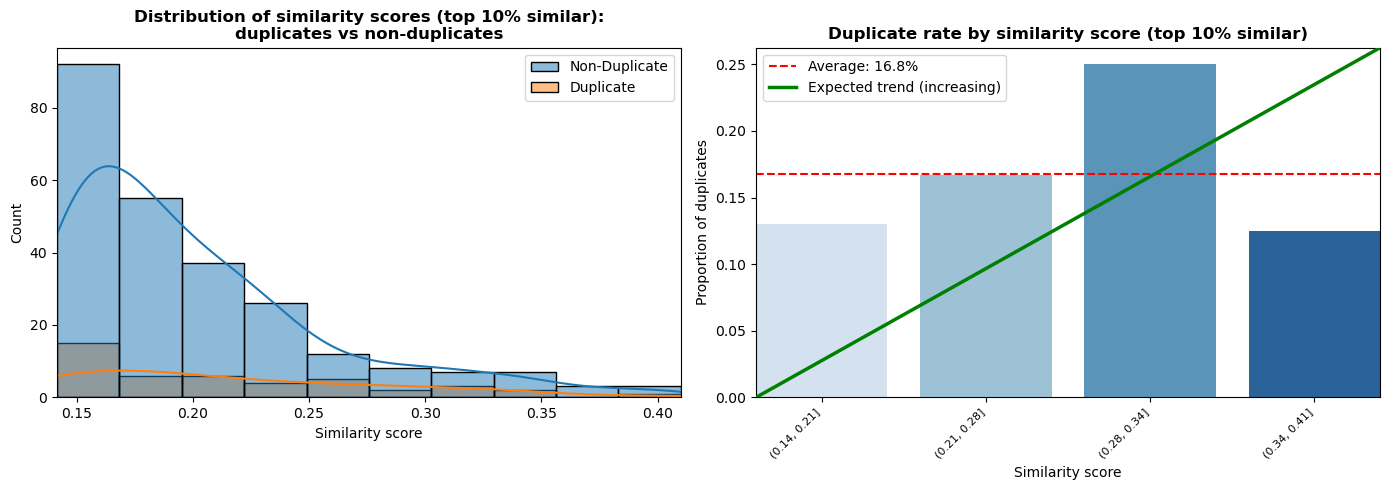


=== Summary ===
Total rows: 294
Duplicates: 44 (15.0%)
Non-duplicates: 250 (85.0%)

Score range: 0.142 to 0.410


In [183]:
# create the plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution
sns.histplot(
    data=df_top_similarity,
    x='similarity_score',
    hue='_is_duplicate',
    hue_order=[False, True],
    bins=10,
    alpha=0.5,
    ax=axes[0],
    kde=True
)
axes[0].margins(x=0)
axes[0].set_title('Distribution of similarity scores (top 10% similar):\nduplicates vs non-duplicates', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Similarity score')
axes[0].set_ylabel('Count')
leg = axes[0].get_legend()
if leg is not None:
    handles = leg.legend_handles
    axes[0].legend(handles=handles, labels=['Non-Duplicate', 'Duplicate'], title=None)

# Plot 2: Duplicate rate by bin
df_top_similarity['score_bin'] = pd.cut(df_top_similarity['similarity_score'], bins=4, precision=2)
bin_stats = df_top_similarity.groupby('score_bin').agg(
    total_count=('_is_duplicate', 'count'),
    duplicate_rate=('_is_duplicate', 'mean')
).reset_index()

sns.barplot(
    data=bin_stats,
    x='score_bin',
    y='duplicate_rate',
    ax=axes[1],
    palette='Blues'
)

axes[1].margins(x=0)  # remove horizontal padding
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1].set_title('Duplicate rate by similarity score (top 10% similar)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Similarity score')
axes[1].set_ylabel('Proportion of duplicates')

# add average line
axes[1].axhline(y=bin_stats['duplicate_rate'].mean(), color='red', linestyle='--', 
                label=f'Average: {bin_stats["duplicate_rate"].mean():.1%}')

# add diagonal line from bottom-left to top-right for "ideal"
axes[1].plot([0, 1], [0, 1], color='green', linestyle='-', linewidth=2.5, 
             transform=axes[1].transAxes, label='Expected trend (increasing)', zorder=5)
axes[1].legend()

plt.tight_layout()
plt.savefig('output/similarity_score_duplicates_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# summary
print(f"\n=== Summary ===")
print(f"Total rows: {len(df_top_similarity)}")
print(f"Duplicates: {df_top_similarity['_is_duplicate'].sum()} ({df_top_similarity['_is_duplicate'].mean():.1%})")
print(f"Non-duplicates: {(~df_top_similarity['_is_duplicate']).sum()} ({(~df_top_similarity['_is_duplicate']).mean():.1%})")
print(f"\nScore range: {df_top_similarity['similarity_score'].min():.3f} to {df_top_similarity['similarity_score'].max():.3f}")

**want to check what these plots look like with all databases, not just the top 10% similar ones; i.e. what's the distribution of duplicates among all databses?**

we would expect more duplicates with higher similarity scores! that would mean our similarity approach was giving us meaningful results, the top 10% actually contain more covid-19 repos

In [156]:
with open("data/cosine_databases.json", "r") as f:
    cosine_results = json.load(f)

In [159]:
rows = []

for item in cosine_results:
    rec = item['repo']
    score = item['similarity_score']

    attrs = rec.get("attributes", {})
    meta = attrs.get("metadata", {})

    row = {
        "name": meta.get("name"),
        "abbreviation": attrs.get("abbreviation"),
        "url": meta.get("homepage"),
        "similarity_score": score
    }

    rows.append(row)

df_all_similarity = pd.DataFrame(rows)

df_all_similarity = df_all_similarity.sort_values(
    by="similarity_score",
    ascending=False,
    ignore_index=True
) 

In [160]:
print(len(df_all_similarity))
df_all_similarity.head(10)

2938


,name,abbreviation,url,similarity_score
0,German Portal for Medical Research Data,FDPG,https://forschen-fuer-gesundheit.de/,0.410045
1,Vivli,Vivli,https://vivli.org/,0.406009
2,HUNT Databank,None,https://hunt-db.medisin.ntnu.no/hunt-db/,0.398216
3,International Traditional Medicine Clinical Tr...,ISRCTN Registry,http://www.isrctn.com/,0.387687
4,Australian New Zealand Clinical Trials Registry,ANZCTR,http://www.anzctr.org.au/,0.381429
5,UMIN Clinical Trials Registry,UMIN-CTR,https://www.umin.ac.jp/ctr/index.htm,0.363759
6,Models of Infectious Disease Agent Study Catalog,MIDAS Catalog,https://catalog.midasnetwork.us,0.357298
7,Clinical Trials Information System,CTIS,https://euclinicaltrials.eu/,0.348813
8,Overview of Medical Research in the Netherlands,OMON,https://onderzoekmetmensen.nl/en,0.337287
9,HealthData.gov,HealthData.gov,https://www.healthdata.gov/,0.337095


In [162]:
df_all_similarity['_norm_name'] = df_all_similarity['name'].str.lower().str.strip()
df_all_similarity['_norm_abbreviation'] = df_all_similarity['abbreviation'].str.lower().str.strip()
df_all_similarity['_norm_domain'] = df_all_similarity['url'].apply(normalize_url_to_domain)


df_all_similarity = mark_duplicates(df_all_similarity, google_names, google_domains)

print("\n=== Duplicates found in Top Similarity df ===")
similarity_dupes_all = df_all_similarity[df_all_similarity['_is_duplicate']]
print(f"Total: {len(similarity_dupes_all)} duplicates out of {len(df_all_similarity)}\n")
similarity_duplicates[['name', 'abbreviation', 'similarity_score', 'url', '_matched_to', '_match_type']]


=== Duplicates found in Top Similarity df ===
Total: 191 duplicates out of 2938



,name,abbreviation,similarity_score,url,_matched_to,_match_type
1,Vivli,Vivli,0.406009,https://vivli.org/,Vivli Center for Global Clinical Research Data,url
12,National Institute of Mental Health Data Archive,NDA,0.334555,https://nda.nih.gov,National Institutes of Health - National Insti...,url
15,PubMed Central,PMC,0.330892,http://www.ncbi.nlm.nih.gov/pmc/,National Center for Biotechnology Information ...,url
16,The Global Health Observatory,GHO,0.327794,https://www.who.int/data/gho,The WHO Global Clinical Platform for COVID-19,url
17,Medical Information Mart for Intensive Care III,MIMIC-III,0.319815,http://mimic.physionet.org/,medical information mart for intensive care,fuzzy
21,Global Initiative on Sharing Avian Influenza Data,GISAID,0.310563,https://www.gisaid.org/,Global Initiative on Sharing All Influenza Data,url
26,Osteoarthritis Initiative,OAI,0.302539,https://nda.nih.gov/oai,National Institutes of Health - National Insti...,url
33,Population Health Data Archive,PHDA,0.280364,http://www.ncmi.cn/,Chinese Academy of Medical Sciences COVID-19 D...,url
38,National Trauma Data Bank,NTDB,0.275584,https://www.facs.org/quality-programs/trauma/q...,American College of Surgeons COVID-19 Registry,url
40,NICHD Data and Specimen Hub,NICHD DASH,0.270424,https://dash.nichd.nih.gov/,National Institutes of Health - National Insti...,url


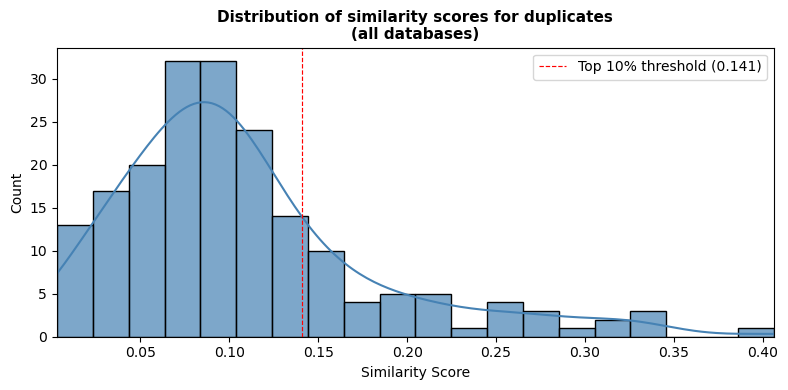


=== Similarity score distribution for 191 duplicates ===
Mean: 0.108
Median: 0.094
Min: 0.003
Max: 0.406
Std Dev: 0.073


In [163]:
# simple histogram of the distribution of duplicates based on similarity score
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=similarity_dupes_all,
    x='similarity_score',
    bins=20,
    kde=True,
    color='steelblue', 
    alpha=0.7,
    ax=ax  
)
ax.margins(x=0)
plt.axvline(x=0.141, color='red', linestyle='--', linewidth=0.85, label='Top 10% threshold (0.141)')
plt.title('Distribution of similarity scores for duplicates\n(all databases)', fontsize=11, fontweight='bold')
plt.xlabel('Similarity Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('output/duplicates_similarity_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# summary stats
print(f"\n=== Similarity score distribution for {len(similarity_dupes_all)} duplicates ===")
print(f"Mean: {similarity_dupes_all['similarity_score'].mean():.3f}")
print(f"Median: {similarity_dupes_all['similarity_score'].median():.3f}")
print(f"Min: {similarity_dupes_all['similarity_score'].min():.3f}")
print(f"Max: {similarity_dupes_all['similarity_score'].max():.3f}")
print(f"Std Dev: {similarity_dupes_all['similarity_score'].std():.3f}")

/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_22392/1451954566.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats_top10 = df_top_similarity.groupby('score_bin').agg(
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_22392/1451954566.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_22392/1451954566.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
/var/folders/dw/5pyz4zx14ngbn

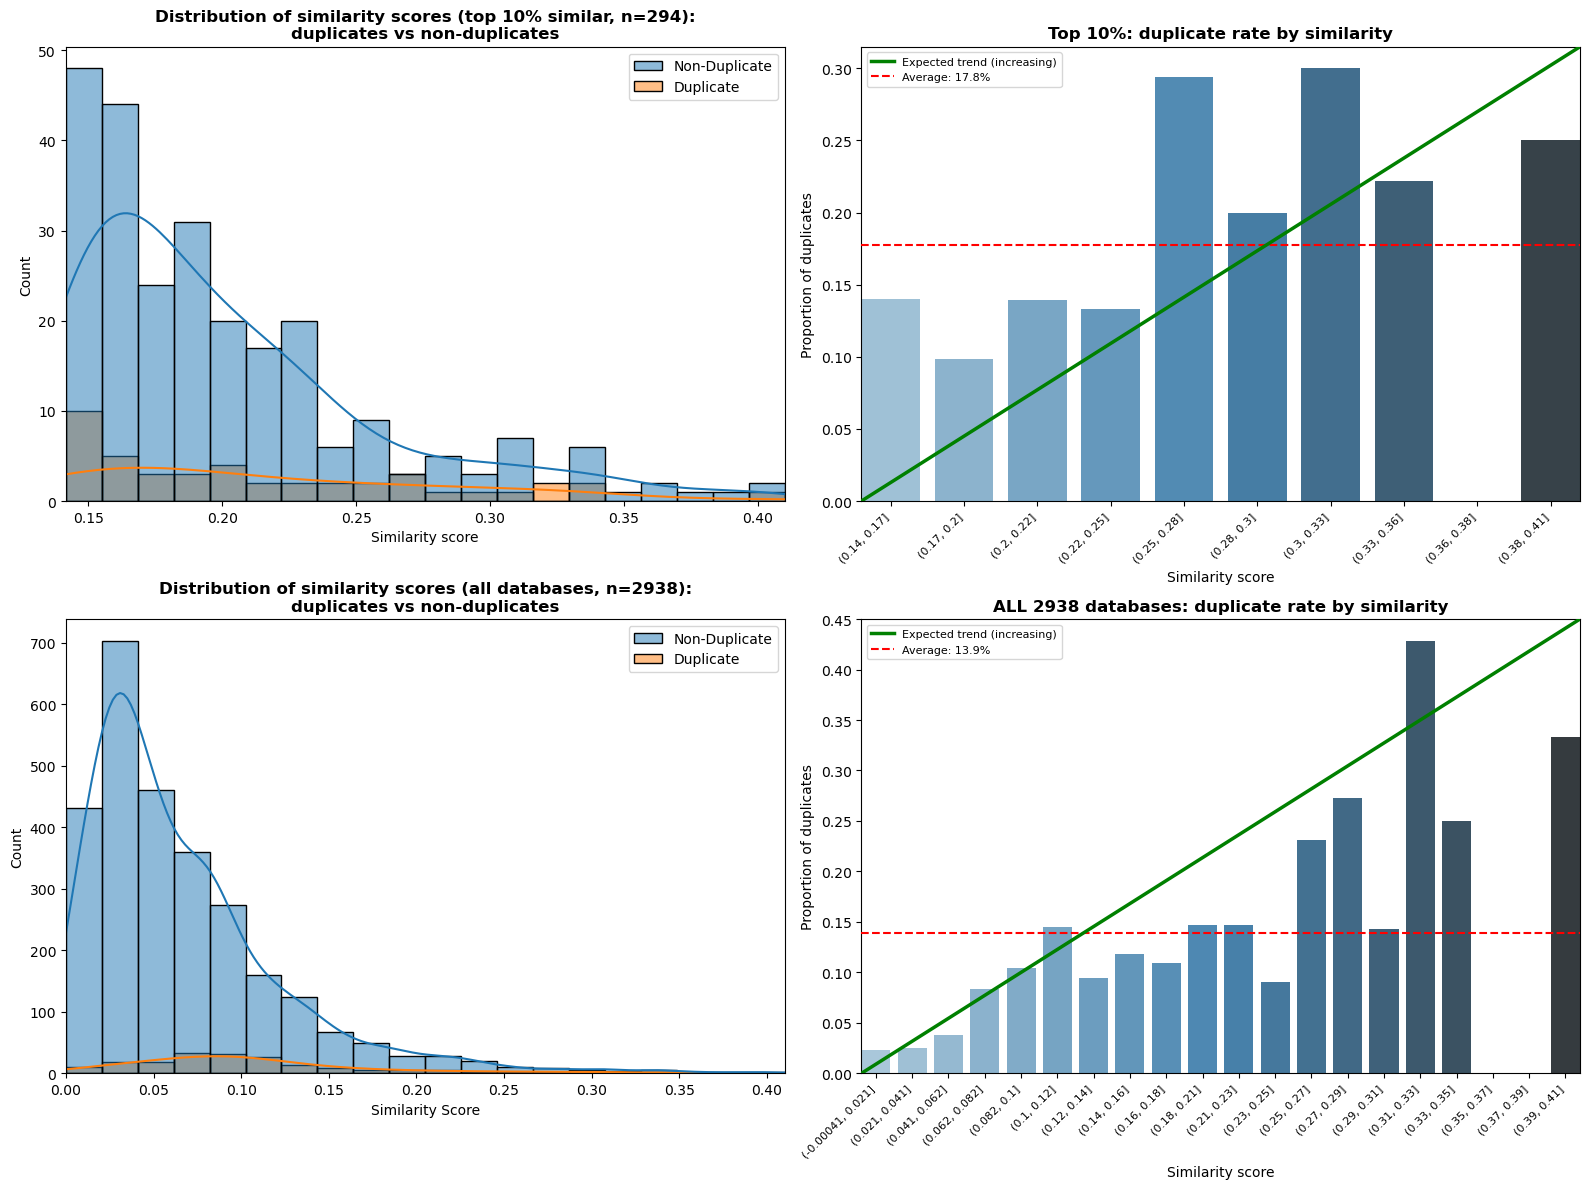


=== Comparison Summary ===

Top 10% (n=294):
  Duplicates: 44 (15.0%)
  Score range: 0.142 - 0.410

ALL 2938 (n=2938):
  Duplicates: 191 (6.5%)
  Score range: 0.000 - 0.410


In [180]:
# Create 2x2 grid: Top 10% (left) vs ALL (right)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =====================
# TOP 10% PLOTS (from before)
# =====================

# Plot 1A: Distribution for top 10%
sns.histplot(
    data=df_top_similarity,
    x='similarity_score',
    hue='_is_duplicate',
    hue_order=[False, True],
    bins=20,
    alpha=0.5,
    ax=axes[0, 0],
    kde=True
)
axes[0, 0].margins(x=0)
axes[0, 0].set_title('Distribution of similarity scores (top 10% similar, n=294):\nduplicates vs non-duplicates', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Similarity score')
axes[0, 0].set_ylabel('Count')

leg = axes[0, 0].get_legend()
if leg is not None:
    handles = leg.legend_handles
    axes[0,0].legend(handles=handles, labels=['Non-Duplicate', 'Duplicate'], title=None)

# Plot 1B: Duplicate rate by bin for top 10%
df_top_similarity['score_bin'] = pd.cut(df_top_similarity['similarity_score'], bins=10, precision=2)
bin_stats_top10 = df_top_similarity.groupby('score_bin').agg(
    total_count=('_is_duplicate', 'count'),
    duplicate_rate=('_is_duplicate', 'mean')
).reset_index()
bin_stats_top10['bin_midpoint'] = bin_stats_top10['score_bin'].apply(lambda x: x.mid)

sns.barplot(
    data=bin_stats_top10,
    x='score_bin',
    y='duplicate_rate',
    ax=axes[0, 1],
    palette='Blues_d'
)
axes[0, 1].margins(x=0)
axes[0, 1].plot([0, 1], [0, 1], color='green', linestyle='-', linewidth=2.5, 
                 transform=axes[0, 1].transAxes, label='Expected trend (increasing)', zorder=5)
axes[0, 1].axhline(y=bin_stats_top10['duplicate_rate'].mean(), color='red', linestyle='--', 
                   label=f'Average: {bin_stats_top10["duplicate_rate"].mean():.1%}', zorder=4)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0, 1].set_title('Top 10%: duplicate rate by similarity', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Similarity score')
axes[0, 1].set_ylabel('Proportion of duplicates')
axes[0, 1].legend(fontsize=8)

plt.tight_layout()

# =====================
# ALL DATABASES PLOTS
# =====================

# Plot 2A: Distribution for ALL
sns.histplot(
    data=df_all_similarity,
    x='similarity_score',
    hue='_is_duplicate',
    hue_order=[False, True],
    bins=20,
    alpha=0.5,
    ax=axes[1, 0],
    kde=True
)
axes[1, 0].margins(x=0)
axes[1, 0].set_title('Distribution of similarity scores (all databases, n=2938):\nduplicates vs non-duplicates', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Similarity Score')
axes[1, 0].set_ylabel('Count')

leg = axes[1, 0].get_legend()
if leg is not None:
    handles = leg.legend_handles
    axes[1,0].legend(handles=handles, labels=['Non-Duplicate', 'Duplicate'], title=None)

# Plot 2B: Duplicate rate by bin for ALL
df_all_similarity['score_bin'] = pd.cut(df_all_similarity['similarity_score'], bins=20, precision=2)
bin_stats_all = df_all_similarity.groupby('score_bin').agg(
    total_count=('_is_duplicate', 'count'),
    duplicate_rate=('_is_duplicate', 'mean')
).reset_index()

sns.barplot(
    data=bin_stats_all,
    x='score_bin',
    y='duplicate_rate',
    ax=axes[1, 1],
    palette='Blues_d'
)
axes[1, 1].margins(x=0)
axes[1, 1].plot([0, 1], [0, 1], color='green', linestyle='-', linewidth=2.5, 
                 transform=axes[1, 1].transAxes, label='Expected trend (increasing)', zorder=5)
axes[1, 1].axhline(y=bin_stats_all['duplicate_rate'].mean(), color='red', linestyle='--', 
                   label=f'Average: {bin_stats_all["duplicate_rate"].mean():.1%}', zorder=4)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1, 1].set_title('ALL 2938 databases: duplicate rate by similarity', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Similarity score')
axes[1, 1].set_ylabel('Proportion of duplicates')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/duplicate_comparison_top10vsall.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary comparison
print("\n=== Comparison Summary ===")
print(f"\nTop 10% (n={len(df_top_similarity)}):")
print(f"  Duplicates: {df_top_similarity['_is_duplicate'].sum()} ({df_top_similarity['_is_duplicate'].mean():.1%})")
print(f"  Score range: {df_top_similarity['similarity_score'].min():.3f} - {df_top_similarity['similarity_score'].max():.3f}")

print(f"\nALL 2938 (n={len(df_all_similarity)}):")
print(f"  Duplicates: {df_all_similarity['_is_duplicate'].sum()} ({df_all_similarity['_is_duplicate'].mean():.1%})")
print(f"  Score range: {df_all_similarity['similarity_score'].min():.3f} - {df_all_similarity['similarity_score'].max():.3f}")

**EXTRACT RE3DATA IDS**

In [188]:
import re
from urllib.parse import urlparse

In [201]:
RE3DATA_URL_TOKEN = "re3data.org/repository/"

def extract_re3data_id(cross_refs):
    if cross_refs is None:
        return None
    if isinstance(cross_refs, float) and pd.isna(cross_refs):
        return None

    if not isinstance(cross_refs, str):
        refs = cross_refs if isinstance(cross_refs, list) else [cross_refs]
    else:
        # Split by semicolon (and optional space after it)
        parts = cross_refs.split(";")
        refs = [p.strip() for p in parts]

    for url in refs:
        if not isinstance(url, str):
            continue

        url = url.strip()

        if RE3DATA_URL_TOKEN not in url.lower():
            continue

        candidate = url.rstrip("/").split("/")[-1]
        candidate = candidate.split("?")[0].split("#")[0].strip()

        if candidate:
            return candidate

    return None


def build_fs_to_re3_mapping(df_list, repo_name_col="name", cross_refs_col="cross_references"):
    mapping = {}
    for df in df_list:
        for _, row in df.iterrows():
            repo_name = row.get(repo_name_col)
            re3_id = extract_re3data_id(row.get(cross_refs_col))
            if pd.notna(repo_name) and re3_id:
                mapping[str(repo_name)] = re3_id
    return mapping



In [202]:
fs_to_re3_mapping = build_fs_to_re3_mapping([df_covid, df_top_similarity])

print(f"Found {len(fs_to_re3_mapping)} repositories with re3data cross-references:")
for name, rid in fs_to_re3_mapping.items():
    print(f"- {name}: {rid}")

Found 189 repositories with re3data cross-references:
- Addgene: r3d100010741
- Antibody Registry: r3d100010408
- Arca Dados: r3d100013904
- BBMRI-ERIC Directory: r3d100013028
- Better Outcomes Registry & Network: r3d100013917
- BioModels: r3d100010789
- BioSamples: r3d100012628
- Biological General Repository for Interaction Datasets: r3d100010350
- CITF DATA PORTAL: r3d100014306
- COVID-19 Data Portal: r3d100013292
- COVID-19 Drug Interactions: r3d100013299
- COVID-19 Research Collaborations: r3d100013300
- Canadian VirusSeq Data Portal: r3d100013955
- Chinese Clinical Trial Registry: r3d100013294
- Comparative Toxicogenomics Database: r3d100011530
- Complex Portal: r3d100013295
- Coronavirus Antiviral Research Database: r3d100013298
- Coronavirus and MS Reporting Database: r3d100014072
- DDBJ Sequence Read Archive: r3d100013696
- DIGITAL.CSIC: r3d100011076
- DisGeNET: r3d100013301
- EMDataResource: r3d100010882
- Ensembl: r3d100010228
- Ensembl Genomes: r3d100011197
- European Centr

In [203]:
with open("../fs_to_re3_mapping.json", "w", encoding="utf-8") as f:
    json.dump(fs_to_re3_mapping, f, indent=2, ensure_ascii=False)